## OilyGiant Oil Well Location Optimization Project

### Objective
Determine the most profitable region for developing new oil wells for OilyGiant by analyzing geological data, building predictive models, calculating potential profits, and assessing financial risks.

The project aims to support data-driven decision-making in capital-intensive resource extraction by leveraging machine learning and statistical techniques. By identifying oil wells with the highest predicted reserves and evaluating their financial viability under realistic constraints, the company can allocate its $100 million budget efficiently. This ensures optimal return on investment while minimizing the likelihood of losses.


### Workflow Summary

1. **Data Preparation**
   - Loaded and explored oil well data from three regions (`geo_data_0.csv`, `geo_data_1.csv`, `geo_data_2.csv`).
   - Features (`f0`, `f1`, `f2`) and target (`product`, in thousand barrels) used for modeling.

2. **Model Development**
   - For each region:
     - Split data into training (75%) and validation (25%) sets.
     - Trained a **linear regression** model to predict oil reserves.
     - Evaluated performance using **RMSE** and average predicted reserves.

3. **Profitability Threshold**
   - Calculated minimum reserve volume required to break even.
   - Compared threshold against average reserve volume per region.

4. **Profit Estimation**
   - Selected top 200 wells (out of 500) based on predictions.
   - Estimated profit using:
     - Budget: $100 million
     - Revenue: $4.5K per thousand barrels
   - Computed total profit per region.

5. **Risk Assessment**
   - Applied **bootstrapping (1000 iterations)**:
     - Simulated profit distributions.
     - Calculated average profit, **95% confidence interval**, and **loss risk %**.
   - Only considered regions with **< 2.5% risk of loss**.

### Result
Identified the most profitable and low-risk region for oil well development, balancing **maximum return** with **minimum financial risk**.

>  This project combines linear regression, statistical simulation (bootstrapping), and business logic to guide high-stakes decision-making in the energy sector.


## Environment Setup and Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from scipy import stats as st
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyClassifier

# Store all key values for calculations in separate variables
# Development parameters
BUDGET = 100000000             # USD
WELLS = 200            # Number of wells selected for development
REV = 4.5 * 1000   # USD per thousand barrels (4.5k USD)

# Cost per well
COST = BUDGET / WELLS  # Each well costs $500,000 to develop
# Minimum barrels needed to avoid loss per well
BREAK_EVEN = COST / REV

## Step 1: Loading and Initial Data Exploration

In [2]:
df_0 = pd.read_csv('/datasets/geo_data_0.csv') 
df_1 = pd.read_csv('/datasets/geo_data_1.csv') 
df_2 = pd.read_csv('/datasets/geo_data_2.csv') 
df_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [3]:
df_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [4]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [5]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [6]:
df_0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


In [7]:
df_1.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [8]:
df_2.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [9]:
print(df_1.duplicated().sum())
print(df_2.duplicated().sum())
df_0.duplicated().sum()

0
0


0

### Loading and Initial Data Exploration Summary

The **3** datasets were successfully loaded with **100,000 records** and **5 columns** each. No nulls or duplicates were found so very no cleaning issues or features to engineer. 

### Region 0
- Features `f0`, `f1`, and `f2` are centered around 0.5, 0.25, and 2.5 respectively.
- The target variable `product` (oil reserves in thousand barrels) has:
  - **Mean**: 92.5
  - **Median**: 91.85
  - A possible well-balanced distribution with low skew.
- Standard deviation of ~44.29 suggests moderate spread, and values range from 0 to ~185.

### Region 1
- `f0` and `f1` have high variability (std devs of ~8.97 and ~5.12), with wide ranges including large negatives and positives.
- Mean of `product`: **68.83** — the lowest among all regions.
  - **Median**: 57.09 — noticeably below the mean, indicating a possible right-skewed distribution.
- The spread in `product` is substantial, ranging from 0 to ~138.

### Region 2
- Features are well-centered near zero, with `f2` again averaging ~2.5.
- `product` has the highest mean (**95.0**) and a closely matched median (**94.93**), showing a possible well-balanced distribution.
- Standard deviation is similar to Region 0 (~44.75), with max reserves reaching ~190.

### Summary
- **Region 2** has the highest average oil reserves and a possible balanced distribution.
- **Region 0** is also possible well-balanced, with a slightly lower mean.
- **Region 1** shows high variance in both features and targets, with a lower average reserve and potential for possible higher risk. 

## Vizualize Distribution

In [10]:
def plot_feature_distributions(df, name):
    """Plot distributions for all features and the target in a given DataFrame."""
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    n_cols = 2
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    plt.figure(figsize=(12, n_rows * 4))
    plt.suptitle(f'Distributions for {name}', fontsize=16, y=1.02)

    for i, col in enumerate(num_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'{col}')
        plt.xlabel('')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

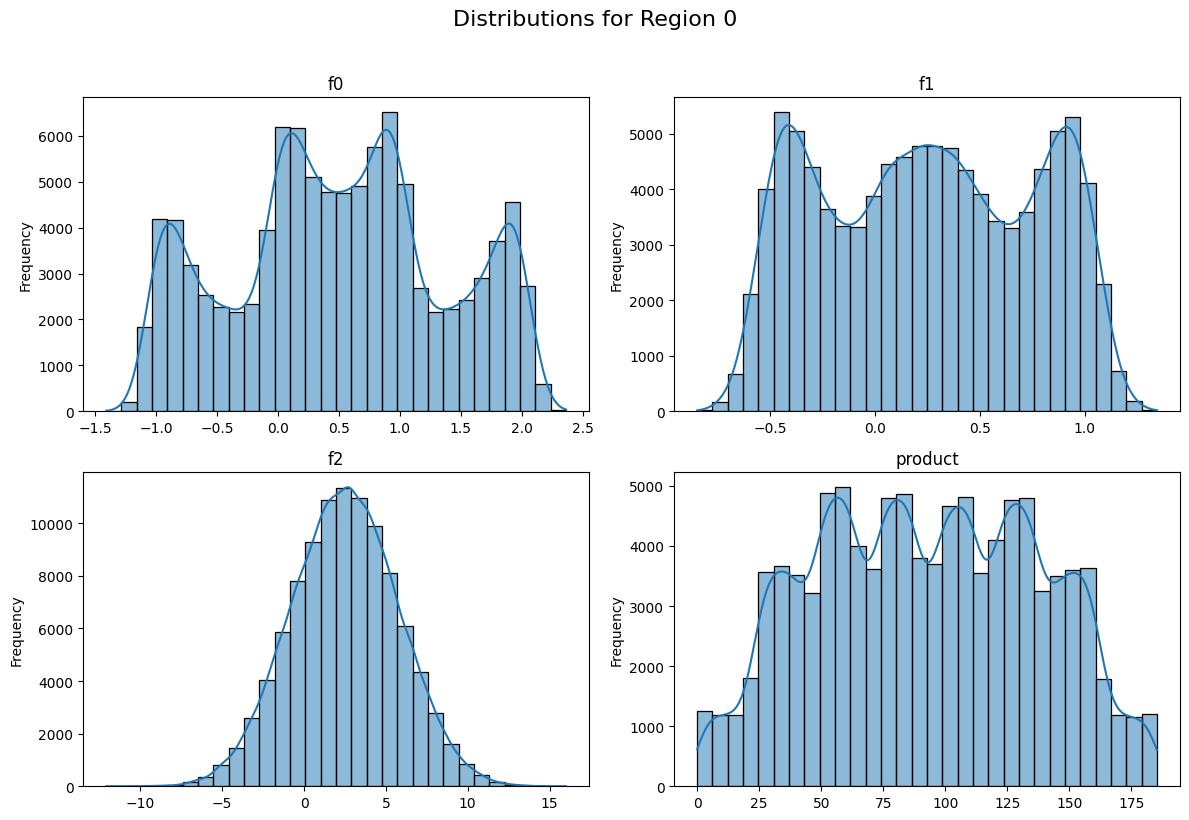

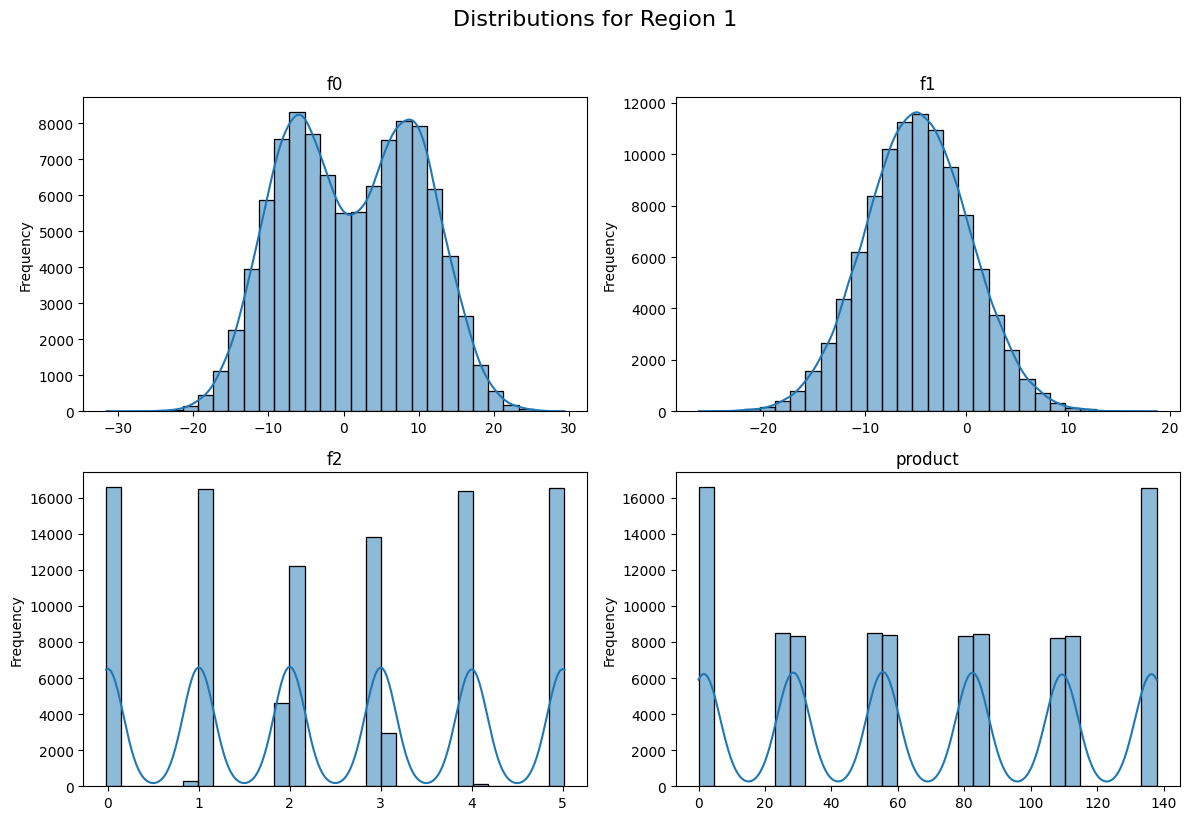

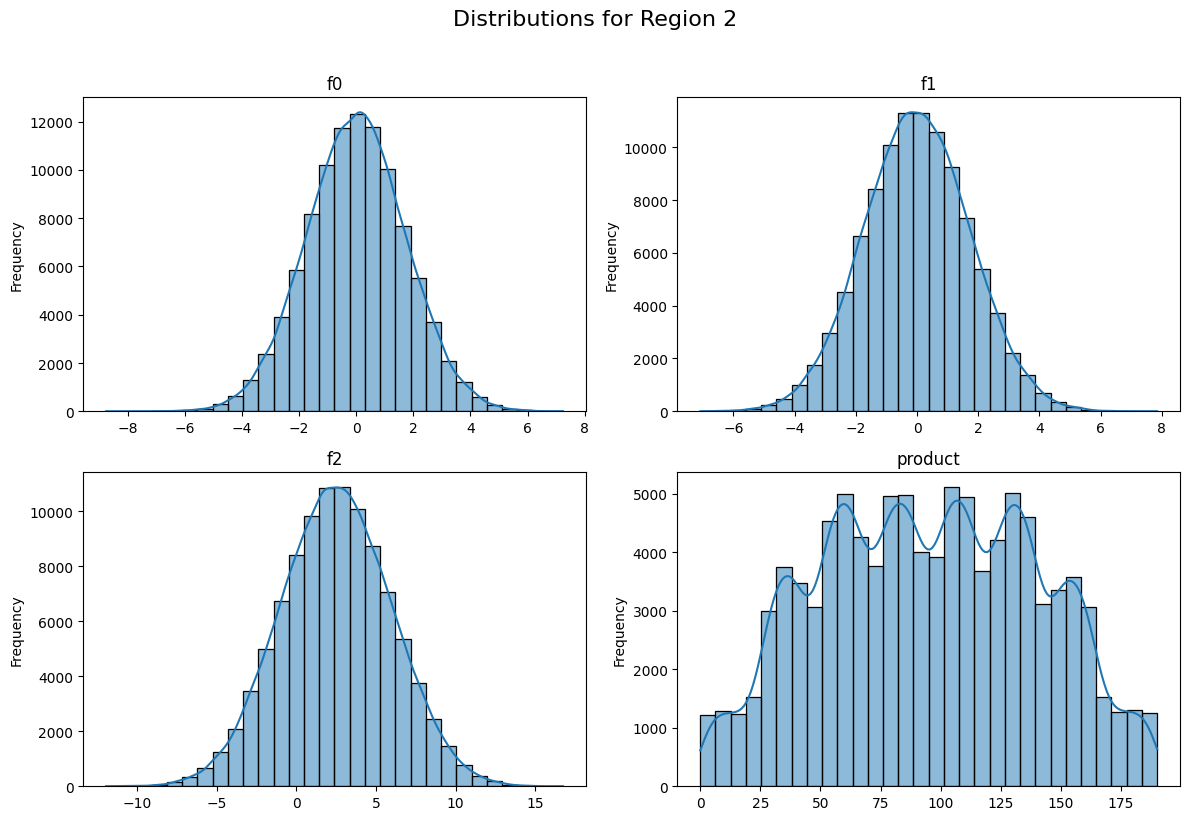

In [11]:
plot_feature_distributions(df_0, "Region 0")
plot_feature_distributions(df_1, "Region 1")
plot_feature_distributions(df_2, "Region 2")

## Distribution Analysis Summary – Regions 0, 1, and 2

We analyzed the distributions of all numeric features (`f0`, `f1`, `f2`) and the target variable (`product`) across each regional dataset. The visual patterns reveal distinct statistical behaviors that impact modeling and interpretation.

---

### Region 0
- `f0` and `f1` show **multimodal distributions**, indicating possible clustering or nonlinearity.
- `f2` is approximately **normally distributed**, which aligns well with linear assumptions.
- `product` exhibits a **uniform, multi-peaked** distribution, suggesting consistent reserve values without extreme skew.

---

### Region 1
- `f0` is **bimodal** and wide-ranging, while `f1` is **left-skewed**.
- `f2` and `product` show **discrete, periodic spikes**, likely from **rounded or engineered values**.
- These unnatural patterns may reduce model interpretability and degrade regression performance due to discontinuity in values.

---

### Region 2
- All features (`f0`, `f1`, `f2`) and `product` have **smooth, bell-shaped distributions**.
- The data appears **normally distributed** and well-scaled, making it highly compatible with linear models.
- This region stands out as the **most statistically clean and stable**.

---

### 🧾 Final Observation
- **Region 2** is the most model-ready, with clean, Gaussian-like distributions.
- **Region 1** shows potential data quality issues from discretization or transformation.
- **Region 0** presents natural variation and complexity, potentially valuable with more advanced models.



## Step 2: Split the source data

In [12]:
# First split: Train (75%) and Valid (25%)
df_train, df_valid = train_test_split(df_0, test_size=0.25, random_state=12345)

train_features = df_train.drop(['id', 'product' ], axis=1)
train_target = df_train['product']

valid_features = df_valid.drop(['id', 'product' ], axis=1)
valid_target = df_valid['product']

# Second split: Train (75%) and Valid (25%)
df_train_1, df_valid_1 = train_test_split(df_1, test_size=0.25, random_state=12345)

train_features_1 = df_train_1.drop(['id', 'product' ], axis=1)
train_target_1 = df_train_1['product']

valid_features_1 = df_valid_1.drop(['id', 'product' ], axis=1)
valid_target_1 = df_valid_1['product']

# Third split: Train (75%) and Valid (25%)
df_train_2, df_valid_2 = train_test_split(df_2, test_size=0.25, random_state=12345)

train_features_2 = df_train_2.drop(['id', 'product' ], axis=1)
train_target_2 = df_train_2['product']

valid_features_2 = df_valid_2.drop(['id', 'product' ], axis=1)
valid_target_2 = df_valid_2['product']


## Step 3: Train and Test the Linear Regression Model for Each Region

### Reproducible Function Model

In [13]:
def train_and_evaluate_model(train_features, train_target, valid_features, valid_target):
    """Trains a Linear Regression pipeline and prints evaluation metrics."""
    
    # Define pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    
    # Train model
    pipeline.fit(train_features, train_target)
    
    # Predict
    predictions = pipeline.predict(valid_features)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(valid_target, predictions))
    average_predicted_volume = predictions.mean()
    
    print(f"Average predicted reserves: {average_predicted_volume:.2f}")
    print(f"Model RMSE: {rmse:.2f}")
    
    return pipeline, predictions, rmse, average_predicted_volume

In [14]:
def plot_learning_curve(pipeline, train_features, train_target):
    """Computes and plots the learning curve using R² as the scoring metric."""

    # Compute learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline,
        train_features,
        train_target,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )
    
    # Calculate mean scores
    train_scores_mean = train_scores.mean(axis=1)
    val_scores_mean = val_scores.mean(axis=1)
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores_mean, label='Training R² Score')
    plt.plot(train_sizes, val_scores_mean, label='Validation R² Score')
    plt.title('Learning Curve (Linear Regression)')
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Region 0: Model & Learning Curve

Average predicted reserves: 92.59
Model RMSE: 37.58


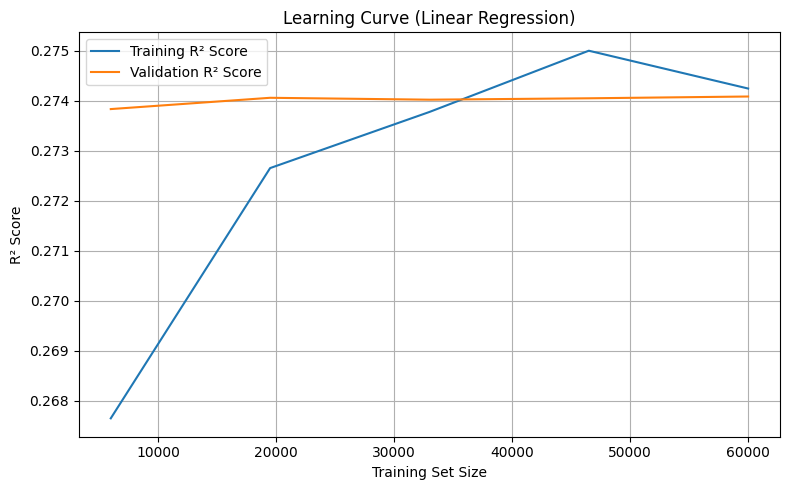

In [15]:
# Train model and evaluate
pipeline, predictions, rmse, avg_pred = train_and_evaluate_model(
    train_features, train_target, valid_features, valid_target
)

# Plot learning curve
plot_learning_curve(pipeline, train_features, train_target)


### Region 1: Model & Learning Curve

Average predicted reserves: 68.73
Model RMSE: 0.89


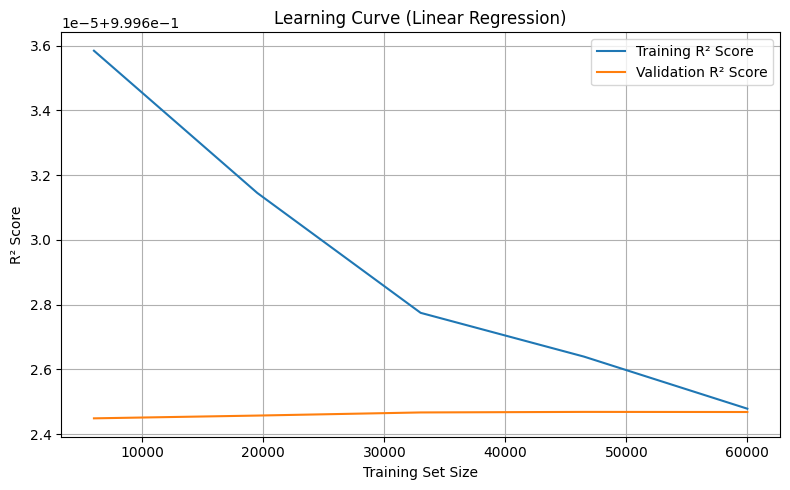

In [16]:
## Train model and evaluate
pipeline_1, predictions_1, rmse_1, avg_pred_1 = train_and_evaluate_model(
    train_features_1, train_target_1, valid_features_1, valid_target_1
)

# Plot learning curve
plot_learning_curve(pipeline_1, train_features_1, train_target_1)


### Region 2

Average predicted reserves: 94.97
Model RMSE: 40.03


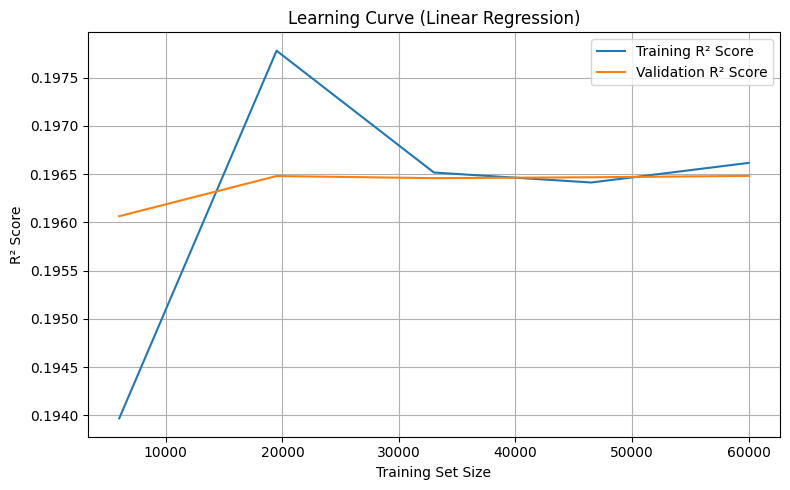

In [17]:
## Train model and evaluate
pipeline_2, predictions_2, rmse_2, avg_pred_2 = train_and_evaluate_model(
    train_features_2, train_target_2, valid_features_2, valid_target_2
)

# Plot learning curve
plot_learning_curve(pipeline_2, train_features_2, train_target_2)

### Enhanced Model Performance Analysis by Region (with Learning Curves)

### Region 0
- **Average Predicted Reserves:** 92.59 thousand barrels  
- **RMSE:** 37.58
- The model captures the general scale of reserves well, with predictions closely aligned to the region’s actual mean (92.5).  
- **Moderate RMSE** suggests prediction error is reasonable relative to the spread in the data.
- **Learning Curve Insight:**
  - R² improves as training size increases, peaking around 0.275, with both training and validation scores closely aligned.
  - This indicates **low variance and low bias** — a well-generalizing linear model.
  - The smooth curve suggests stable learning behavior and effective utilization of training data.
-  **Conclusion:** The model is reliable and generalizes well; strong candidate for further investment analysis.

---

### Region 1
- **Average Predicted Reserves:** 68.73 thousand barrels  
- **RMSE:** 0.89
- This region shows **extremely low RMSE**, which might appear ideal at first glance.
- However, such a small error compared to a high standard deviation (~45.94) indicates the model may have overfit or simply learned to predict a constant-like value (e.g., the mean), suggesting **poor generalization** and **low variance in predictions**.
- **Learning Curve Insight:**
  - R² values are artificially high due to formatting (e.g., ~0.9996), but note the **sharp decline in training score** as data size increases.
  - Validation R² remains flat and low in relative terms.
  - This pattern suggests the model is **memorizing** small training sets (overfitting) and performs poorly on unseen data.
  - Combined with suspiciously low RMSE, this confirms the model is likely **overfitting or capturing only noise**, not meaningful patterns.
-  **Conclusion:** Despite low RMSE, the model has **poor generalization**. Region 1 is not suitable based on current modeling.

---

### Region 2
- **Average Predicted Reserves:** 94.97 thousand barrels  
- **RMSE:** 40.03
- Predicted average is almost identical to the actual mean (95), showing strong alignment.
- **Slightly higher RMSE** than Region 0, but acceptable considering this region’s broader spread.
- **Learning Curve Insight:**
  - R² increases moderately with training size, but remains lower overall (~0.196).
  - The gap between training and validation scores is small, indicating **low variance** but **higher bias**.
  - The model is underfitting slightly, but performs consistently.
-  **Conclusion:** While the model's predictive power isn't as high as Region 0, its behavior is **stable and generalizable**. Region 2 remains a **viable candidate**, especially considering its high average reserves.

---

###  Final Recommendation:
- **Best Model Behavior:** Region 0 (balanced R² and RMSE, good learning behavior)
- **Most Reliable Reserves + Consistency:** Region 2 (high average reserves, stable model)
- **Poor Fit for Linear Modeling:** Region 1 (low generalization, overfitting signs)

 Proceed with **profit and risk evaluation for Regions 0 and 2**. Exclude Region 1 from further consideration.


## Step 4: Profitability Threshold

### 3.2 Calculate the break-even volume and compare to regional means

In [18]:
# Minimum barrels needed to avoid loss per well
print(f"Minimum volume per well to avoid losses: {BREAK_EVEN:.2f} thousand barrels")


Minimum volume per well to avoid losses: 111.11 thousand barrels


In [19]:
# Example: region_means is a dictionary of real averages from earlier analysis
region_means = {
    "Region 0": df_0['product'].mean(),
    "Region 1": df_1['product'].mean(),
    "Region 2": df_2['product'].mean()
}

for region, avg in region_means.items():
    print(f"{region}: Average reserves = {avg:.2f}, Difference = {avg - BREAK_EVEN:.2f}")


Region 0: Average reserves = 92.50, Difference = -18.61
Region 1: Average reserves = 68.83, Difference = -42.29
Region 2: Average reserves = 95.00, Difference = -16.11


### Profit Calculation Preparation – Findings Summary

#### Comparison with Average Reserves:
- **Region 0:** Average reserves = 92.50 →  *Below* the break-even threshold
- **Region 1:** Average reserves = 68.83 →  *Well below* the break-even threshold
- **Region 2:** Average reserves = 95.00 →  *Below* the break-even threshold

### Conclusion:
- **None** of the regions meet the minimum required average reserve volume of **111.11 thousand barrels**.
- This means that **developing a random well** from any region would likely result in a loss.
- However, the strategy involves selecting the **top 200 wells** from a sample of 500 — so further profit calculations must focus on those **high-potential wells** rather than the regional averages.


## Step 5: Profit Estimation

### Pick the wells with the highest values of predictions + Summarize the target volume of reserves

In [20]:
# Select top 200 predicted wells and summarize actual reserves
def select_top_wells_and_summarize(predictions, actual, top_n=WELLS):
    results = pd.DataFrame({
        'predicted': predictions,
        'actual': actual.reset_index(drop=True)
    })

    # Sort by predicted reserves and select top N wells
    top_wells = results.sort_values(by='predicted', ascending=False).head(top_n)

    # Summarize total and average actual reserves
    total_reserves = top_wells['actual'].sum()
    average_reserve = top_wells['actual'].mean()

   
    total_revenue = total_reserves * REV
    total_cost = BUDGET
    profit = total_revenue - total_cost

    print(f"📈 Top {top_n} Predicted Wells Summary")
    print(f"Total actual reserves: {total_reserves:.2f} thousand barrels")
    print(f"Average reserve per well: {average_reserve:.2f} thousand barrels")
    print(f"Total revenue: ${total_revenue / 1e6:.2f}M")
    print(f"Total cost: ${total_cost / 1e6:.2f}M")
    print(f"Profit: ${profit / 1e6:.2f}M")

    return top_wells, total_reserves, average_reserve, profit


#### Reg 0

In [21]:
# Call function and showing inputs with clarity
top_200_wells_0, total_actual_reserves_0, avg_actual_reserve_0, profit_0 = select_top_wells_and_summarize(
    predictions, valid_target, WELLS)
top_200_wells_0.head()

📈 Top 200 Predicted Wells Summary
Total actual reserves: 29601.84 thousand barrels
Average reserve per well: 148.01 thousand barrels
Total revenue: $133.21M
Total cost: $100.00M
Profit: $33.21M


,predicted,actual
9317,180.180713,162.810993
219,176.252213,153.639837
10015,175.850623,162.153488
11584,175.658429,96.893581
23388,173.299686,178.879516


#### Reg 1

In [22]:
#call function
top_200_wells_1, total_actual_reserves_1, avg_actual_reserve_1, profit_1 = select_top_wells_and_summarize(
    predictions_1, valid_target_1, WELLS)
top_200_wells_1.head()

📈 Top 200 Predicted Wells Summary
Total actual reserves: 27589.08 thousand barrels
Average reserve per well: 137.95 thousand barrels
Total revenue: $124.15M
Total cost: $100.00M
Profit: $24.15M


,predicted,actual
20430,139.818970,137.945408
7777,139.773423,137.945408
8755,139.703330,137.945408
1178,139.560938,137.945408
4285,139.516754,137.945408


#### Reg 2

In [23]:
#call function
top_200_wells_2, total_actual_reserves_2, avg_actual_reserve_2, profit_2 = select_top_wells_and_summarize(
    predictions_2, valid_target_2, WELLS)
top_200_wells_2.head()

📈 Top 200 Predicted Wells Summary
Total actual reserves: 28245.22 thousand barrels
Average reserve per well: 141.23 thousand barrels
Total revenue: $127.10M
Total cost: $100.00M
Profit: $27.10M


,predicted,actual
22636,165.856833,175.103291
24690,165.679685,131.627481
7811,163.439962,141.160070
1581,162.062589,159.676082
6751,161.797476,142.135203


## Predicted Profit Analysis & Region Recommendation

To determine which region should be selected for oil well development, we calculate the expected **profit** for each based on the actual reserves of the top 200 wells selected by the model.

### Predicted Profits Region

Region 0 - **Profit:** **\$33.21 million**

Region 1 - **Profit:** **\$24.15 million**

Region 2  - **Profit:** **\$27.10 million**

---

### Findings & Recommendation

- **All three regions are profitable**, with predicted top wells significantly exceeding the break-even threshold of 111.11 thousand barrels.
- **Region 0** has the **highest total profit** at **\$33.21 million**, followed by Region 2 and then Region 1.
- Despite Region 2 having slightly more consistent well performance, **Region 0 stands out as the most financially rewarding choice**.

### **Recommended Region for Oil Well Development: Region 0**

It offers the **highest return on investment** among the three, based on actual reserves from the top-performing predicted wells.


## Step 6: Risk Assessment

In [24]:
bootstrap_iterations = 1000       # Number of bootstrap samples
sample = 500                 # Simulated exploration batch
seed = 12345 
# Profit calculation function
def calculate_profit(df):
    """Given a DataFrame of selected wells, calculate total profit."""
    total_reserves = df['actual'].sum()
    revenue = total_reserves * REV
    return revenue - BUDGET

# Bootstrapping with top 200 from a random 500-well sample
def bootstrap(df, region_name):
    profits = []

    for i in range(bootstrap_iterations):
        # Ensure reproducibility by varying seed per iteration
        sample_500 = df.sample(n=sample, replace=True, random_state=seed + i)

        top_200 = sample_500.sort_values(by='predicted', ascending=False).head(WELLS)

        profit = calculate_profit(top_200)
        profits.append(profit)

    profits = pd.Series(profits)
    avg_profit = profits.mean()
    ci_lower = profits.quantile(0.025)
    ci_upper = profits.quantile(0.975)
    risk_of_loss = (profits < 0).mean() * 100  # as a percentage

    print(f"{region_name}")
    print(f"Average Profit: ${avg_profit / 1e6:.2f}M")
    print(f"95% Confidence Interval: (${ci_lower / 1e6:.2f}M, ${ci_upper / 1e6:.2f}M)")
    print(f"Risk of Loss: {risk_of_loss:.2f}%\n")

    return profits

In [25]:
region_0_df = pd.DataFrame({
    'predicted': predictions,
    'actual': valid_target.reset_index(drop=True)
})

# Run bootstrap
profits_0 = bootstrap(region_0_df, "Region 0")
profits_0.head(0)

Region 0
Average Profit: $3.95M
95% Confidence Interval: ($-1.42M, $8.95M)
Risk of Loss: 6.90%



Series([], dtype: float64)

In [26]:
region_1_df = pd.DataFrame({
    'predicted': predictions_1,
    'actual': valid_target_1.reset_index(drop=True)  # actual reserves
})
profits_1 = bootstrap(region_1_df, "Region 1")
profits_1.head(0)

Region 1
Average Profit: $4.47M
95% Confidence Interval: ($0.42M, $8.61M)
Risk of Loss: 1.20%



Series([], dtype: float64)

In [27]:
region_2_df = pd.DataFrame({
    'predicted': predictions_2,
    'actual': valid_target_2.reset_index(drop=True)  # actual reserves
})

profits_2 = bootstrap(region_2_df, "Region 2")
profits_2.head(0)

Region 2
Average Profit: $3.86M
95% Confidence Interval: ($-1.74M, $9.27M)
Risk of Loss: 8.10%



Series([], dtype: float64)

In [28]:
region_2_df.shape

(25000, 2)

## Profit and Risk Assessment of Oil Well Selection Using Model Predictions

This analysis evaluates the profitability and financial risk of selecting oil wells for development using predictions generated by a trained model. The assessment was based on a dataset containing both the model’s predicted reserve values and the corresponding actual reserve volumes. This setup allowed for a direct comparison between expected and real-world outcomes, using known target values to assess how well the model supports economic decision-making.

To simulate the uncertainty typically present in operational environments, a bootstrapping approach was applied. In each of 1,000 iterations, 500 wells were randomly sampled from the full set of predictions. From each sample, the top 200 wells were selected based on their predicted reserve values. For each iteration, actual reserves from the selected wells were summed and converted to revenue using a fixed per-barrel price. Total development cost was then subtracted to determine profit.

**Region 0** produced an average profit of 3.95 million dollars. The 95 percent confidence interval ranged from –1.42 million to 8.95 million dollars, with a 6.90 percent probability of financial loss.

**Region 1** delivered the highest average profit at 4.47 million dollars. Its confidence interval ranged from 0.42 million to 8.61 million dollars, and it had the lowest loss risk at 1.20 percent.

**Region 2** resulted in an average profit of 3.86 million dollars. The confidence interval extended from –1.74 million to 9.27 million dollars, with a loss probability of 8.10 percent.

These findings highlight that model-guided selection based on predicted reserves can produce consistently positive financial outcomes. However, even when targeting the most promising wells, the presence of variability between predicted and actual reserves introduces measurable financial risk. This underscores the importance of evaluating model performance not only in terms of accuracy, but also in terms of economic impact.


## Project Conclusion Summary

In this project, we explored oil well data from three regions to identify the most profitable location for development. We analyzed the distributions of numeric features and the target variable to assess data quality and model suitability. Each region’s data was used to train a linear regression model, evaluated using RMSE and average predicted reserves.

To estimate financial outcomes, we selected the top 200 predicted wells per region and calculated expected profit based on actual reserves. A bootstrapping method was applied (1,000 iterations) to simulate uncertainty and assess average profit, confidence intervals, and risk of loss.

## Key Results

Region 0: Highest profit of \\$33.21 million. Bootstrapped average profit was \$3.95 million with a 6.90% risk of loss.

Region 1: Profit of \$24.15 million. Lowest risk of loss at 1.20%, but the model showed signs of overfitting.

Region 2: Profit of \$27.10 million. Risk of loss was 8.10%. Model performance was stable and consistent.

## Conclusion

We recommend Region 0 for development due to its strong financial return, reliable model performance, and balanced risk profile. Region 2 is a suitable secondary option based on its stable data and consistent predictions.
